In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from functions import *
from scipy.linalg import toeplitz

plt.rcParams.update({'font.size': 12})

C:\Users\Tadej\AppData\Local\Temp\ipykernel_229048\611083885.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
val2 = pd.read_csv("data/val2.dat")
val3 = pd.read_csv("data/val3.dat")
co2 = pd.read_csv("data/co2.dat", skiprows=16, delimiter=' ')

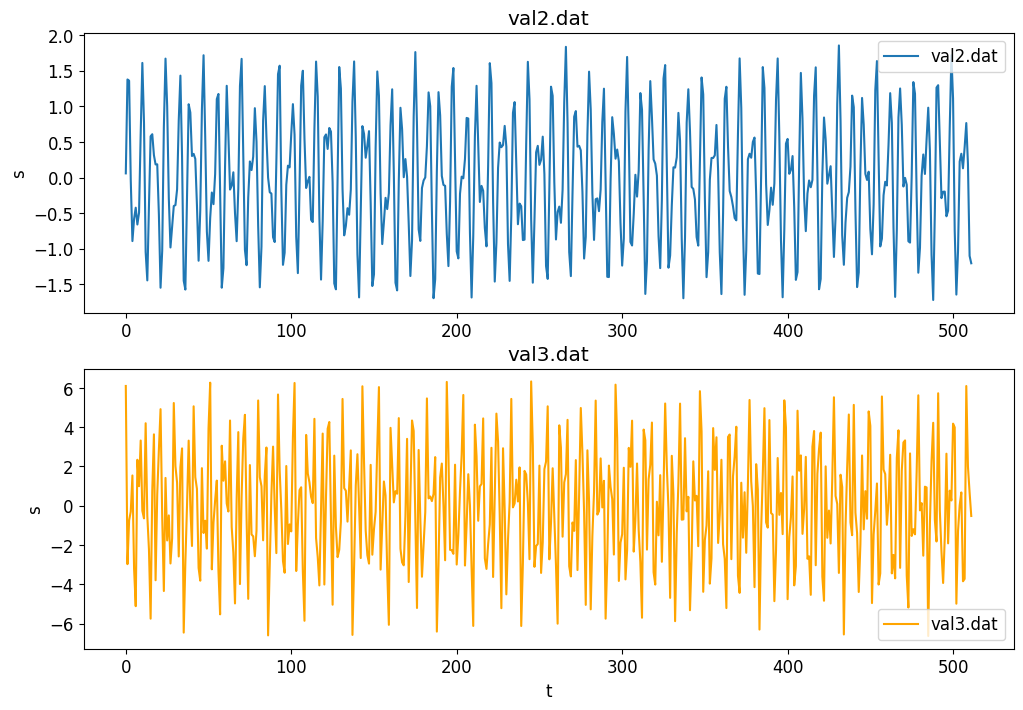

In [3]:
fig = plt.figure(figsize=(12, 8))

ax = fig.add_subplot(2, 1, 1)
ax.set_title('val2.dat')
ax.plot(val2.index, val2['value'].values, label='val2.dat')
ax.set_ylabel('s')
ax.legend()

ax = fig.add_subplot(2, 1, 2)
ax.set_title('val3.dat')
ax.plot(val3.index, val3['value'].values, color='orange', label='val3.dat')
ax.set_ylabel('s')
ax.set_xlabel('t')
ax.legend()

In [4]:
N = len(val3['value'].values)
dt = 1.

nuc = 1. / (2. * dt)
nus = np.linspace(0., nuc, round(N/2)) * 2 * np.pi
dnu = nus[1]-nus[0]

omegas = np.linspace(0., np.pi, round(N/2))

S2, P2 = DFT(val2['value'].values)
S2_Welch, P2_Welch = DFT(val2['value'].values, window='Welch')
poles, adjusted_poles, P2_3 = MESE(omegas, val2['value'].values, 3, 'Reflect')
poles, adjusted_poles, P2_14 = MESE(omegas, val2['value'].values, 4, 'Reflect')
poles, adjusted_poles, P2_25 = MESE(omegas, val2['value'].values, 14, 'Reflect')


S3, P3 = DFT(val3['value'].values)
S3_Welch, P3_Welch = DFT(val3['value'].values, window='Welch')
poles, adjusted_poles, P3_3 = MESE(omegas, val3['value'].values, 3, 'Reflect')
poles, adjusted_poles, P3_14 = MESE(omegas, val3['value'].values, 6, 'Reflect')
poles, adjusted_poles, P3_25 = MESE(omegas, val3['value'].values, 9, 'Reflect')

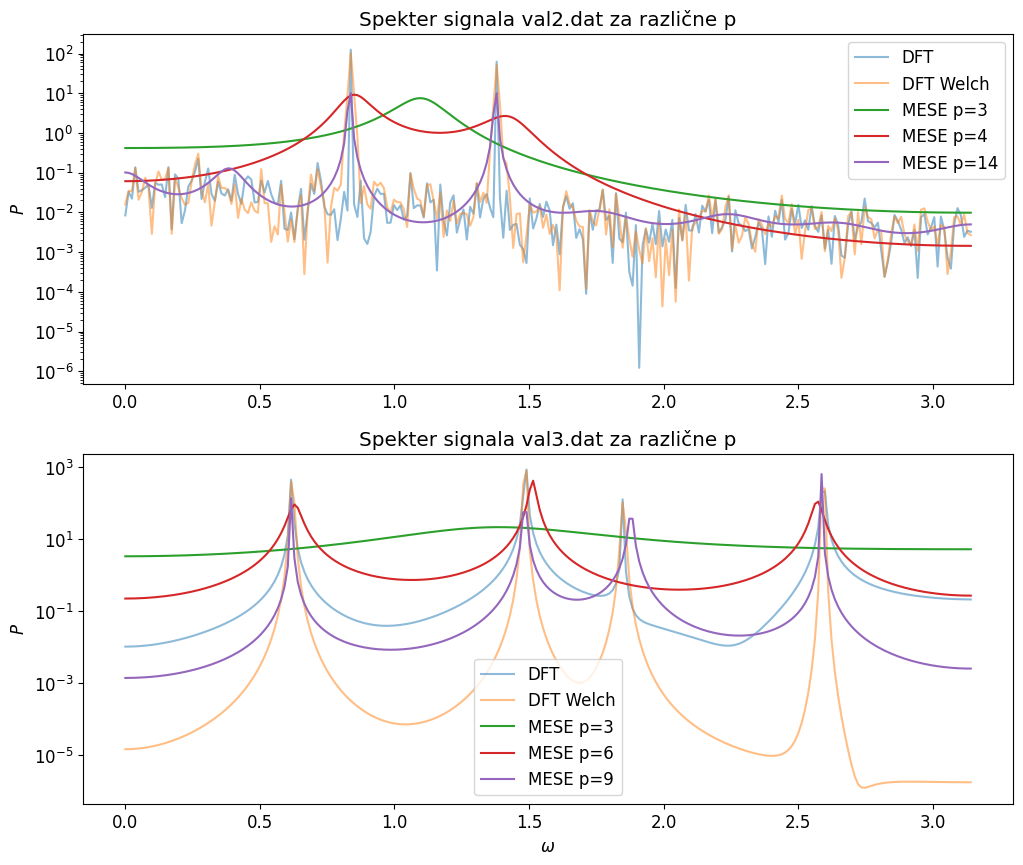

In [5]:
fig = plt.figure(figsize=(12, 10))

ax = fig.add_subplot(2, 1, 1)
ax.set_title('Spekter signala val2.dat za različne p')
ax.set_ylabel(r'$P$')
ax.set_yscale('log')
ax.plot(nus, P2, label='DFT', alpha=0.5)
ax.plot(nus, P2_Welch, label='DFT Welch', alpha=0.5)
ax.plot(nus, P2_3, label='MESE p=3')
ax.plot(nus, P2_14, label='MESE p=4')
ax.plot(nus, P2_25, label='MESE p=14')
#ax.set_ylim((0.0001, 100))
ax.legend()

ax = fig.add_subplot(2, 1, 2)
ax.set_title('Spekter signala val3.dat za različne p')
ax.set_xlabel(r'$\omega$')
ax.set_ylabel(r'$P$')
ax.set_yscale('log')
ax.plot(nus, P3, label='DFT', alpha=0.5)
ax.plot(nus, P3_Welch, label='DFT Welch', alpha=0.5)
ax.plot(nus, P3_3, label='MESE p=3')
ax.plot(nus, P3_14, label='MESE p=6')
ax.plot(nus, P3_25, label='MESE p=9')
ax.legend()

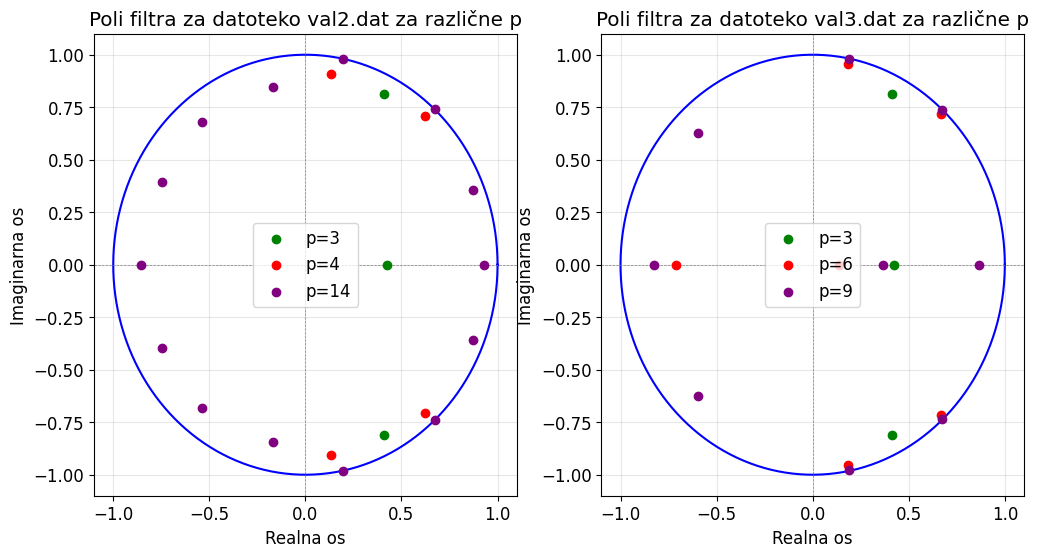

In [6]:
val2_poles_3 = find_poles(val2['value'].values, 3)
val2_poles_8 = find_poles(val2['value'].values, 4)
val2_poles_14 = find_poles(val2['value'].values, 14)

val3_poles_3 = find_poles(val2['value'].values, 3)
val3_poles_6 = find_poles(val2['value'].values, 6)
val3_poles_9 = find_poles(val2['value'].values, 9)

# Create the unit circle
theta = np.linspace(0, 2 * np.pi, 500)
unit_circle = np.exp(1j * theta)

# Create figure
fig = plt.figure(figsize=(12, 6))

# Create axis
ax = fig.add_subplot(1, 2, 1)

# Plot the unit circle
ax.plot(unit_circle.real, unit_circle.imag, 'b-',)

# Plot the val2_poles
ax.scatter(val2_poles_3.real, val2_poles_3.imag, color='green', label="p=3", zorder=5)
ax.scatter(val2_poles_8.real, val2_poles_8.imag, color='red', label="p=4", zorder=5)
ax.scatter(val2_poles_14.real, val2_poles_14.imag, color='purple', label="p=14", zorder=5)

# Formatting the plot
ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.5)
ax.set_title("Poli filtra za datoteko val2.dat za različne p")
ax.set_xlabel("Realna os")
ax.set_ylabel("Imaginarna os")
ax.grid(alpha=0.3)
ax.legend()

# Create axis
ax = fig.add_subplot(1, 2, 2)

# Plot the unit circle
ax.plot(unit_circle.real, unit_circle.imag, 'b-',)

# Plot the val2_poles
ax.scatter(val3_poles_3.real, val3_poles_3.imag, color='green', label="p=3", zorder=5)
ax.scatter(val3_poles_6.real, val3_poles_6.imag, color='red', label="p=6", zorder=5)
ax.scatter(val3_poles_9.real, val3_poles_9.imag, color='purple', label="p=9", zorder=5)

# Formatting the plot
ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.5)
ax.set_title("Poli filtra za datoteko val3.dat za različne p")
ax.set_xlabel("Realna os")
ax.set_ylabel("Imaginarna os")
ax.grid(alpha=0.3)
ax.legend()